In [ ]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
DATA_DIR = PROJECT_ROOT / "data"

def read_json(file_path):
    data = None
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def read_jsonl(file_path: Path) -> list:
    res = []
    with open(file_path, "r") as f:
        for line in f:
            res.append(json.loads(line))
    return res

In [3]:
PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/matthewho/Documents/research/ctx_editor


In [4]:
def read_json(file_path):
    data = None
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def read_jsonl(file_path: Path) -> list:
    res = []
    with open(file_path, "r") as f:
        for line in f:
            res.append(json.loads(line))
    return res

In [5]:
lcbh_path = PROJECT_ROOT / "data/lcb_hard_sharded.json"
lcbh = read_json(lcbh_path)

In [6]:
print(list(lcbh[0].keys()))

['question', 'full_spec_q', 'shards', '_segments', 'task_id', 'private_test_cases', 'question_title', 'difficulty', 'contest_id', 'contest_date', 'platform', 'starter_code', 'metadata', 'public_test_cases']


In [12]:
for shard in lcbh[0]["shards"]:
    print(json.dumps(shard, indent=2))

{
  "shard_id": 1,
  "shard": "count pairings into N white-black pairs that make the final digraph strongly connected (answer mod 998244353)"
}
{
  "shard_id": 2,
  "shard": "start with a directed graph that has 2N vertices and 2N-1 edges"
}
{
  "shard_id": 3,
  "shard": "vertices are labeled 1..2N and there are edges i -> i+1 for i = 1..2N-1 (a directed path)"
}
{
  "shard_id": 4,
  "shard": "you're given a string S of length 2N that contains exactly N 'W' and N 'B'"
}
{
  "shard_id": 5,
  "shard": "vertex i is white when S_i == 'W'"
}
{
  "shard_id": 6,
  "shard": "vertex i is black when S_i == 'B'"
}
{
  "shard_id": 7,
  "shard": "then you will do the following operations on that graph"
}
{
  "shard_id": 8,
  "shard": "pair up all 2N vertices into N pairs, each pair must have one white and one black vertex"
}
{
  "shard_id": 9,
  "shard": "for every pair, add a directed edge from the white vertex to the black vertex"
}
{
  "shard_id": 10,
  "shard": "compute how many pairing choices

In [7]:
# load original dataset
original_data_path = PROJECT_ROOT / "data/sharded_instructions_600.json"
original_data = read_json(original_data_path)

Distribution of number of shards per category:
code: {8: 21, 7: 19, 10: 9, 6: 21, 4: 9, 9: 9, 5: 12}
humaneval: {8: 5, 7: 5, 10: 3, 6: 11, 4: 9, 9: 3, 5: 9}
livecodebench: {10: 6, 8: 16, 7: 14, 6: 10, 5: 3, 9: 6}
database: {4: 68, 5: 27, 6: 4, 3: 6, 7: 2}
actions: {6: 44, 10: 2, 4: 13, 5: 31, 7: 12, 9: 2, 8: 1}
math: {4: 22, 7: 14, 8: 9, 5: 30, 6: 26, 9: 1, 12: 1}
data2text: {6: 102, 7: 18}
summary: {7: 27, 8: 12, 6: 36, 9: 10, 10: 7}


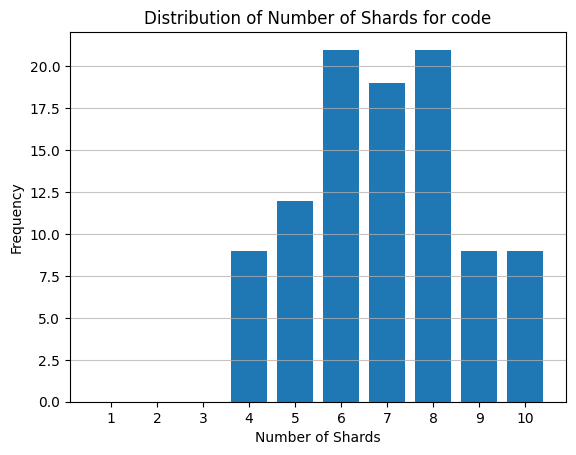

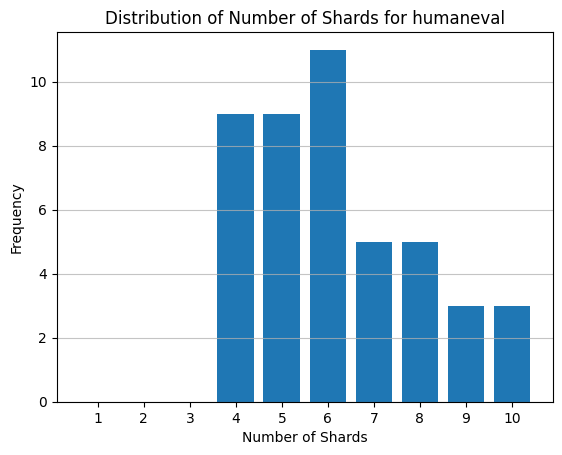

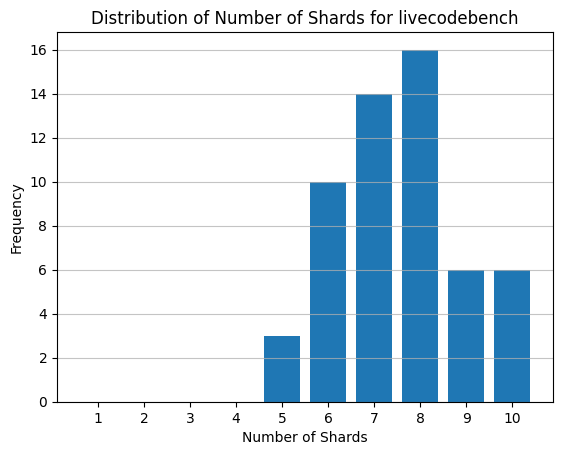

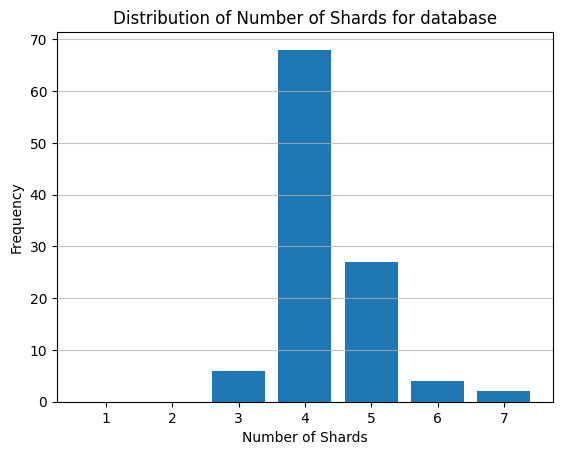

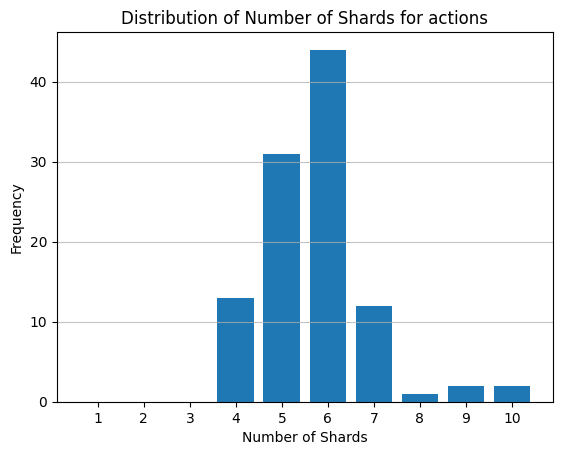

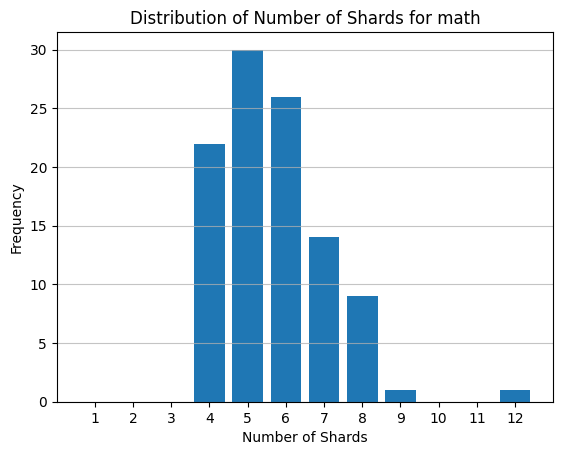

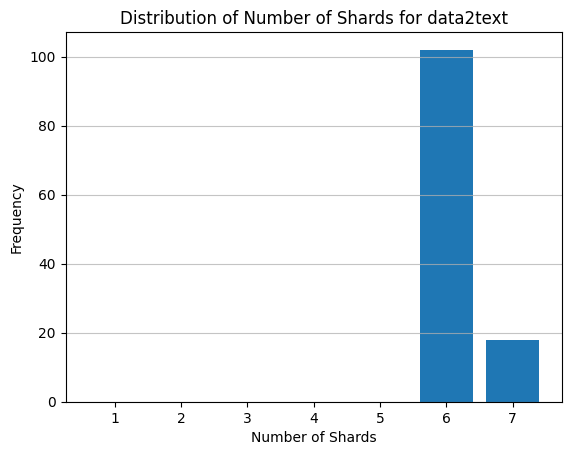

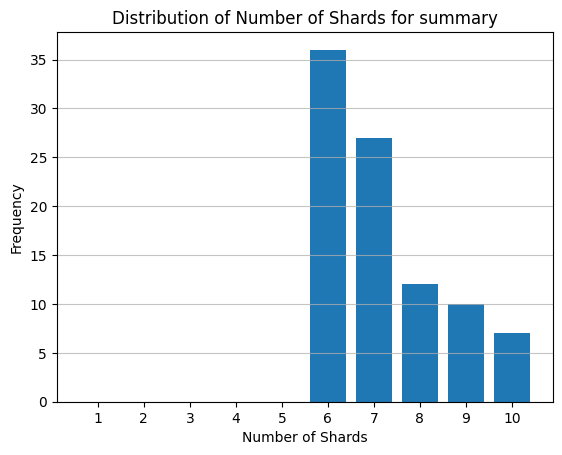

In [11]:
# checking distribution of how many shards per task type
# also add separate categories for humaneval and livecodebench tasks
# so have categories for code, math, actions, database AND humaneval, livecodebench
# this will double count code but thatss ok
num_shards_per_category = defaultdict(list)
for item in original_data:
    task_category = item["task"]
    num_shards = len(item["shards"])
    num_shards_per_category[task_category].append(num_shards)
    if task_category == "code":
        if "humaneval" in item["task_id"].lower():
            num_shards_per_category["humaneval"].append(num_shards)
        elif "livecodebench" in item["task_id"].lower():
            num_shards_per_category["livecodebench"].append(num_shards)
print("Distribution of number of shards per category:")
for category, shard_counts in num_shards_per_category.items():
    count_distribution = Counter(shard_counts)
    print(f"{category}: {dict(count_distribution)}")

# create histogram for each
for category, shard_counts in num_shards_per_category.items():
    plt.figure()
    plt.hist(shard_counts, bins=range(1, max(shard_counts) + 2), align="left", rwidth=0.8)
    plt.title(f"Distribution of Number of Shards for {category}")
    plt.xlabel("Number of Shards")
    plt.ylabel("Frequency")
    plt.xticks(range(1, max(shard_counts) + 1))
    plt.grid(axis="y", alpha=0.75)
    plt.show()

In [16]:
# randomly sample a couple of original examples with task code and task_id with LCB
lcb_examples = []
for item in original_data:
    if item["task"] == "code" and "livecodebench" in item["task_id"].lower():
        lcb_examples.append(item)
print(f"Found {len(lcb_examples)} LiveCodeBench examples in original data")

sampled_lcb_examples = random.sample(lcb_examples, min(3, len(lcb_examples)))
print("Sampled LiveCodeBench examples:")
for example in sampled_lcb_examples:
    # print(json.dumps(example, indent=2))
    # nicely print:
    # - first the title and difficulty, the platform, and question_id
    # then the question_content
    # then the shards
    print(f"Title: {example['question_title']}")
    print(f"Difficulty: {example['difficulty']}")
    print(f"Platform: {example['platform']}")
    print(f"Question ID: {example['question_id']}")
    print("Question content:\n---\n")
    print(example["question_content"])
    print("\n---\nShards:")
    for shard in example["shards"]:
        print(json.dumps(shard, indent=2))
    print("-" * 50)

Found 55 LiveCodeBench examples in original data
Sampled LiveCodeBench examples:
Title: ways-to-express-an-integer-as-sum-of-powers
Difficulty: medium
Platform: leetcode
Question ID: 2882
Question content:
---

Given two positive integers n and x.
Return the number of ways n can be expressed as the sum of the x^th power of unique positive integers, in other words, the number of sets of unique integers [n_1, n_2, ..., n_k] where n = n_1^x + n_2^x + ... + n_k^x.
Since the result can be very large, return it modulo 10^9 + 7.
For example, if n = 160 and x = 3, one way to express n is n = 2^3 + 3^3 + 5^3.
 
Example 1:

Input: n = 10, x = 2
Output: 1
Explanation: We can express n as the following: n = 3^2 + 1^2 = 10.
It can be shown that it is the only way to express 10 as the sum of the 2^nd power of unique integers.

Example 2:

Input: n = 4, x = 1
Output: 2
Explanation: We can express n in the following ways:
- n = 4^1 = 4.
- n = 3^1 + 1^1 = 4.

 
Constraints:

1 <= n <= 300
1 <= x <= 5



In [17]:
lcbh2_path = PROJECT_ROOT / "data/lcb_hard_sharded2.json"
lcbh2 = read_json(lcbh2_path)

In [23]:
lcbh2[0].keys()

dict_keys(['question', 'full_spec_q', 'shards', '_segments', 'task_id', 'starter_code', 'question_title', 'contest_id', 'private_test_cases', 'public_test_cases', 'contest_date', 'difficulty', 'metadata', 'platform'])

In [24]:
def pretty_print_lcb_example(ex):
    print(f"Title: {ex['question_title']}")
    print(f"Difficulty: {ex['difficulty']}")
    print(f"Platform: {ex['platform']}")
    print(f"Question ID: {ex['task_id']}")
    print("Question content:\n---\n")
    print(ex["question"])
    print("\n---\nShards:")
    for shard in ex["shards"]:
        print(json.dumps(shard, indent=2))
    print("-" * 50)

In [26]:
pretty_print_lcb_example(lcbh2[1])

Title: Complete Binary Tree
Difficulty: hard
Platform: atcoder
Question ID: abc321_e
Question content:
---

There is a tree with N vertices numbered 1 to N.
For each i\ (2 \leq i \leq N), there is an edge connecting vertex i and vertex \lfloor \frac{i}{2} \rfloor.
There are no other edges.
In this tree, find the number of vertices whose distance from vertex X is K.
Here, the distance between two vertices u and v is defined as the number of edges in the simple path connecting vertices u and v.
You have T test cases to solve.

Input

The input is given from Standard Input in the following format, where \mathrm{test}_i represents the i-th test case:
T
\mathrm{test}_1
\mathrm{test}_2
\vdots
\mathrm{test}_T

Each test case is given in the following format:
N X K

Output

Print T lines.
The i-th line (1 \leq i \leq T) should contain the answer to the i-th test case as an integer.

Constraints


- 1\leq T \leq 10^5
- 1\leq N \leq 10^{18}
- 1\leq X \leq N
- 0\leq K \leq N-1
- All input values 

In [28]:
lcb_examples[0].keys()

dict_keys(['question_title', 'question_content', 'platform', 'question_id', 'contest_id', 'contest_date', 'starter_code', 'difficulty', 'public_test_cases', 'private_test_cases', 'metadata', 'task_id', 'source', 'shards', 'task'])

In [38]:
# get distribution of platforms in original LiC LCB data
lic_platform_counts = Counter()
for ex in lcb_examples:
    lic_platform_counts[ex["platform"]] += 1
    # print(f"diff: {ex['difficulty']}, platform: {ex['platform']}, question_id: {ex['question_id']}")
print("Distribution of platforms in original LiC LCB data:")
for platform, count in lic_platform_counts.items():
    print(f"{platform}: {count}")

Distribution of platforms in original LiC LCB data:
leetcode: 55


In [34]:
# read in lcb_ha
lcbh_full_input_path = PROJECT_ROOT / "data/lcb_hard_input_full.json"
lcbh_full_input = read_json(lcbh_full_input_path)

In [37]:
# let's get distribution of platform
platform_counts = Counter()
for ex in lcbh_full_input:
    platform_counts[ex["platform"]] += 1
print("Distribution of platforms in LCB hard input:")
for platform, count in platform_counts.items():
    print(f"{platform}: {count}")

Distribution of platforms in LCB hard input:
codeforces: 3
leetcode: 102
atcoder: 245


### let's look at the hard task outputs

In [39]:
LIC_LOGS_DIR = PROJECT_ROOT / "src/lic/logs"

In [42]:
full_code = read_jsonl(LIC_LOGS_DIR / "code/full/full_code_gpt-5-mini.jsonl")

In [ ]:
full_code[]

[{'conv_id': '699424806e6711294680cfac',
  'conv_type': 'full',
  'task': 'code',
  'task_id': 'sharded-livecodebench/3688',
  'dataset_fn': 'hard_task_san_check.json',
  'assistant_model': 'gpt-5-mini',
  'system_model': 'NA',
  'user_model': 'NA',
  'git_version': 'efacb732ab53d63451077dd0c1b63eded8234ba9',
  'trace': [{'role': 'system',
    'content': 'You are an expert Python programmer. You will be given a question (problem specification) and will generate a correct Python program that matches the specification and passes all tests.\n\nFormat:\n- [Standalone] Make sure that your answer consists of only one Python function at the top level. Do not wrap with a class or split into multiple functions.'},
   {'role': 'user',
    'content': '### Question:\nYou are given an integer array nums.\nYou can do the following operation on the array at most once:\n\nChoose any integer x such that nums remains non-empty on removing all occurrences of x.\nRemove all occurrences of x from the array